In [1]:
# Importar dependências

# Gerenciamento de dados e viz
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Progress bar e config
from tqdm.auto import tqdm  # Barra de progresso
from dotenv import load_dotenv  # Carregar env vars

# Métricas de classificação (evaluation)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# SDK Typesafe para chamadas ao Jev
from typesafe_sdk import TypeSafeClient, Noul

/home/leonardo/Documentos/github/jev_laya_studies/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Classificação de Tweets com Jev

Avaliação do modelo Jev em tarefa de classificação binária: detectar tweets que relatam desastres reais.

**Dataset**: tweets rotulados (desastre/não-desastre)  
**Abordagem**: Usar Jev com tipo `Noul` (probabilidade) para cada tweet em batch  
**Objetivo**: Medir acurácia, comparar com baseline, otimizar threshold e investigar a decisão com explicabilidade estruturada


In [2]:
# Configurações de predição
BATCH_SIZE = 32      # Processar 32 tweets por chamada à API (eficiência)
THRESHOLD = 0.5      # Threshold inicial para converter probabilidade em classe binária

In [3]:
# Carregar variáveis de ambiente para acesso à API
load_dotenv()

True

In [4]:
# Carregar dataset de tweets com label (desastre: 0/1)
# ref.: https://www.kaggle.com/competitions/nlp-getting-started
df = pd.read_csv("disaster_tweets.csv")

df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
# Examinar estrutura: 7613 tweets, algumas colunas com missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [6]:
# Distribuição de classes: desbalanceado (57% não-desastre, 43% desastre)
df["target"].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [7]:
# Proporção (normalizado)
df["target"].value_counts(normalize=True)

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

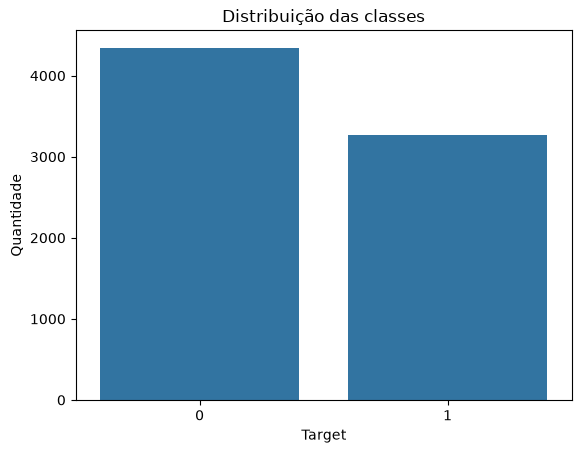

In [8]:
# Visualizar distribuição de classes
sns.countplot(
    data=df,
    x="target"
)

plt.title("Distribuição das classes")
plt.xlabel("Target")
plt.ylabel("Quantidade")
plt.show()

## Preparação do Dataset

Split 80/20 com estratificação para manter proporções de classe

In [9]:
# Separar 20% para teste (stratified split)
_, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["target"]
)

In [10]:
# Reset índices após split
df_test = df_test.reset_index(drop=True)

print(df_test.shape)  # 1523 tweets (20% do dataset)
df_test.head()

(1523, 5)


,id,keyword,location,text,target
0,6925,mass%20murderer,"Huntsville, AL",@TheEconomist Step one: get that mass murderer...,0
1,1975,bush%20fires,Queen Creek AZ,Ted Cruz fires back at Jeb &amp; Bush: ÛÏWe l...,0
2,5034,eyewitness,NaN,How ÛÏLittle BoyÛ Affected the People In Hi...,1
3,254,ambulance,Happily Married with 2 kids,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...,0
4,8370,ruin,NaN,'Cause you play me like a symphony play me til...,0


In [11]:
# Usar apenas 200 tweets para avaliação (por custo de API)
N_SAMPLES = 200

In [12]:
# Extrair subset estratificado de N_SAMPLES tweets para avaliação
df_eval, _ = train_test_split(
    df_test,
    train_size=N_SAMPLES,
    random_state=42,
    stratify=df_test["target"]
)

df_eval = df_eval.reset_index(drop=True)

In [13]:
## Funções de Predição

def predict_batch(client, batch):
    """
    Enviar batch de tweets para Jev para classificação.
    
    Estratégia: Uma pergunta Noul por tweet (P(desastre)).
    Jev responde tudo em uma única chamada.
    """
    
    # Estruturar input: lista de tweets com metadados
    state = {
        "tweets": [
            {
                "text": row["text"],
                "keyword": (
                    row["keyword"]
                    if pd.notna(row["keyword"])
                    else None
                ),
                "location": (
                    row["location"]
                    if pd.notna(row["location"])
                    else None
                ),
            }
            for _, row in batch.iterrows()
        ]
    }

    # Criar Noul independente para cada tweet
    # Instrução: "É um desastre real? (não para metáforas, ficção, promoção)"
    questions = {
        f"tweet_{i}": Noul(
            instructions=(
                f"Does `tweets[{i}].text` describe or report a real-world "
                "disaster or emergency event? "
                "Return yes for actual events such as fires, floods, earthquakes, "
                "storms, accidents, explosions, attacks, evacuations, casualties "
                "or similar emergencies. "
                "Return no when disaster-related language is metaphorical, "
                "figurative, humorous, promotional, fictional, or otherwise "
                "does not describe a real-world disaster or emergency."
            )
        )
        for i in range(len(batch))
    }

    # Chamada única à API com todas as perguntas
    response = client.system_one(
        state=state,
        questions=questions,
    )

    # Extrair P(desastre) para cada tweet
    probabilities = [
        response.answers[f"tweet_{i}"].noul
        for i in range(len(batch))
    ]

    return probabilities

In [14]:
def predict_dataset(df, batch_size=32):
    """
    Classificar dataset inteiro em batches.
    
    Args:
        df: DataFrame com tweets
        batch_size: Número de tweets por chamada API
    
    Returns:
        Array de probabilidades (0-1)
    """
    
    probabilities = []

    with TypeSafeClient() as client:

        # Iterar em batches
        for start in tqdm(range(0, len(df), batch_size)):

            end = min(
                start + batch_size,
                len(df)
            )

            batch = df.iloc[start:end]

            # Chamar Jev com batch
            batch_probabilities = predict_batch(
                client,
                batch
            )

            probabilities.extend(
                batch_probabilities
            )

            print(
                f"{end}/{len(df)} tweets classificados"
            )

    return np.array(probabilities)

In [15]:
## Predição

# Executar predições com batch_size=32 (eficiência)
y_score = predict_dataset(
    df_eval,
    batch_size=BATCH_SIZE
)

 14%|█▎       | 1/7 [00:00<00:03,  1.99it/s]

32/200 tweets classificados


 29%|██▌      | 2/7 [00:00<00:02,  2.02it/s]

64/200 tweets classificados


 43%|███▊     | 3/7 [00:01<00:01,  2.15it/s]

...

160/200 tweets classificados


 86%|███████▋ | 6/7 [00:02<00:00,  2.89it/s]

192/200 tweets classificados


100%|█████████| 7/7 [00:02<00:00,  2.69it/s]

200/200 tweets classificados


In [16]:
# Primeiras 10 probabilidades (deve ser ~0.5 para ambíguo, 0-0.2 para não-desastre, 0.8+ para desastre)
y_score[:10]

array([0.97, 0.04, 0.09, 0.94, 0.07, 0.43, 0.94, 0.94, 0.07, 0.07])

In [17]:
# Converter probabilidades em predições binárias usando threshold
y_pred = (
    y_score >= THRESHOLD
).astype(int)

In [18]:
# Labels verdadeiros da avaliação
y_true = df_eval["target"].to_numpy()

In [19]:
# Criar DataFrame de resultados com scores e predições
results = df_eval[
    [
        "id",
        "text",
        "target"
    ]
].copy()

results["jev_probability"] = y_score
results["jev_prediction"] = y_pred
results.head(20)

,id,text,target,jev_probability,jev_prediction
0,7498,Refugio oil spill may have been costlier bigge...,1,0.97,1
1,1475,8 hours of bagging groceries = an aching body,0,0.04,0
2,10658,@mattmosley post a pic of your wounds please,0,0.09,0
3,4139,Moderate #drought is spreading rapidly across ...,1,0.94,1
4,6682,'Since1970the 2 biggest depreciations in CAD:U...,0,0.07,0
5,4122,#weed news How marijuana is making California ...,1,0.43,0
6,10194,POV video captures violent landing at Amsterda...,1,0.94,1
7,9813,#NissanNews : Trauma Alert and 1 Child Among 6...,1,0.94,1
8,470,@RohnertParkDPS You're another one for the his...,0,0.07,0
9,54,@PhDSquares #mufc they've built so much hype a...,0,0.07,0


In [20]:
## Avaliação

# Calcular métricas principais
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

roc_auc = roc_auc_score(
    y_true,
    y_score
)

In [21]:
# Resumo de métricas
metrics = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics

,Métrica,Valor
0,Accuracy,0.760000
1,Precision,0.771429
2,Recall,0.627907
3,F1,0.692308
4,ROC AUC,0.833537


In [22]:
# Relatório detalhado por classe
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Não desastre",
            "Desastre"
        ]
    )
)

              precision    recall  f1-score   support

Não desastre       0.75      0.86      0.80       114
    Desastre       0.77      0.63      0.69        86

    accuracy                           0.76       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.76      0.76      0.76       200



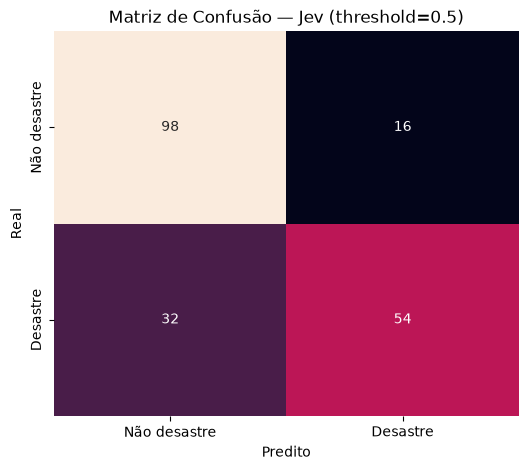

In [23]:
## Visualizações

# Matriz de confusão
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=[
        "Não desastre",
        "Desastre"
    ],
    yticklabels=[
        "Não desastre",
        "Desastre"
    ],
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(
    f"Matriz de Confusão — Jev (threshold={THRESHOLD})"
)

plt.show()

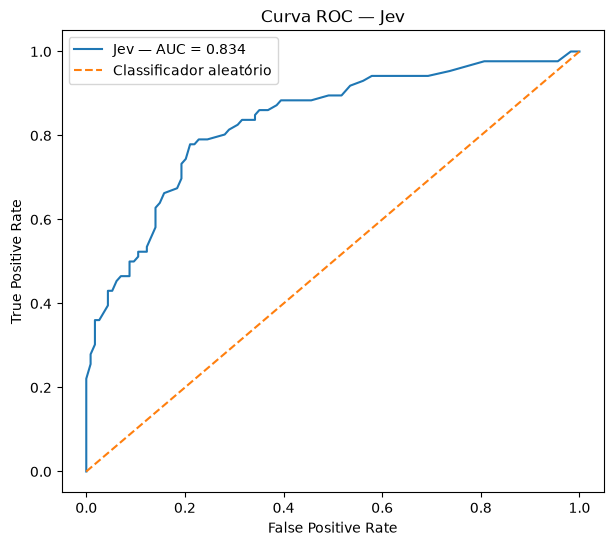

In [24]:
# Curva ROC (AUC = 0.837 indica bom discriminante)
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

auc = roc_auc_score(
    y_true,
    y_score
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Jev — AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Jev")
plt.legend()

plt.show()

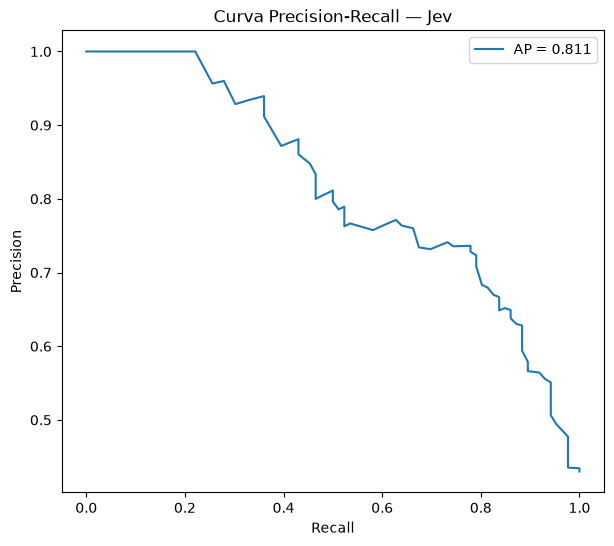

In [25]:
# Curva Precision-Recall (melhor para dados desbalanceados)
precision_curve, recall_curve, thresholds_pr = (
    precision_recall_curve(
        y_true,
        y_score
    )
)

average_precision = average_precision_score(
    y_true,
    y_score
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"AP = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Jev")
plt.legend()

plt.show()

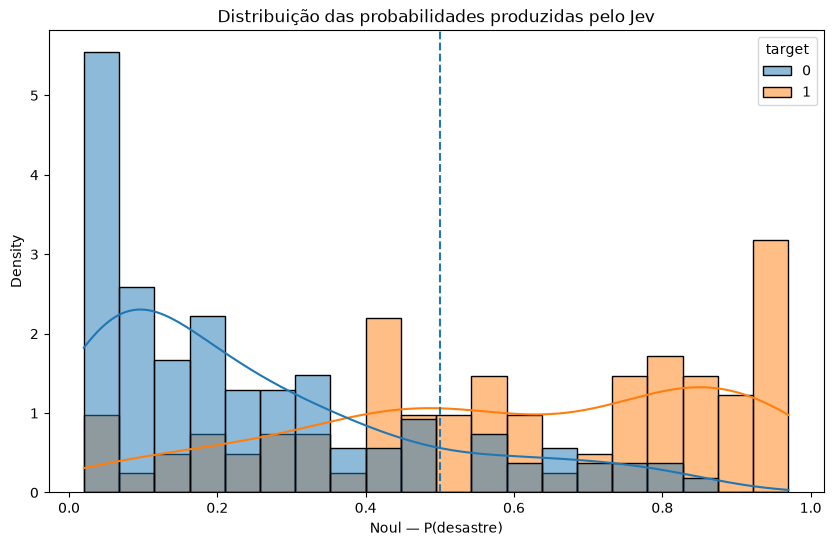

In [26]:
# Distribuição de probabilidades por classe verdadeira
plt.figure(figsize=(10, 6))

sns.histplot(
    data=results,
    x="jev_probability",
    hue="target",
    bins=20,
    kde=True,
    stat="density",
    common_norm=False,
)

plt.axvline(
    THRESHOLD,
    linestyle="--"
)

plt.xlabel("Noul — P(desastre)")
plt.title(
    "Distribuição das probabilidades produzidas pelo Jev"
)

plt.show()

In [27]:
## Análise de Erros

# False positives: predito desastre mas era não-desastre
# Exemplo: linguagem figurada que pareceu real ao Jev
false_positives = results[
    (results["target"] == 0)
    &
    (results["jev_prediction"] == 1)
].sort_values(
    "jev_probability",
    ascending=False
)

false_positives[
    [
        "text",
        "target",
        "jev_probability"
    ]
].head(20)

,text,target,jev_probability
90,Hey #AZ: Sign this petition to save the #WildH...,0,0.85
86,@VictoriaGittins what do you take me for I'm n...,0,0.82
62,OH. #TeamHennessy #NJ Obliteration @tprimo24 ...,0,0.78
61,@teamVODG Discovered by @NickCannon \n Listen/...,0,0.77
88,@Homukami Only URs and SRs matter Rs you'll be...,0,0.77
115,Loved the opener and still feeling guilty for ...,0,0.72
29,@Papcrdoll and I s2g if my mentions get blown ...,0,0.70
60,It's like God wants me to become a mass murder...,0,0.68
82,The Danger and Excitement of Underwater Cave D...,0,0.66
28,Versions of KS where if a character was /every...,0,0.65


In [28]:
# False negatives: predito não-desastre mas era desastre
# Exemplo: desastre real descrito de forma vaga ou literal
false_negatives = results[
    (results["target"] == 1)
    &
    (results["jev_prediction"] == 0)
].sort_values(
    "jev_probability"
)

false_negatives[
    [
        "text",
        "target",
        "jev_probability"
    ]
].head(20)

,text,target,jev_probability
192,you can stab me in the back but I promise you'...,1,0.03
167,That horrible sinking feeling when youÛªve be...,1,0.03
137,I just checked in! ÛÒ at On Fire on @ZomatoAU...,1,0.06
171,The Prophet (peace be upon him) said 'Save you...,1,0.06
139,Swansea Û÷plot hijack transfer move for South...,1,0.07
193,@115Film Doctor we must leave immediately the ...,1,0.15
181,@Habbo bring back games from the past. Snowsto...,1,0.16
69,I liked a @YouTube video http://t.co/XO2ZbPBJB...,1,0.17
170,Manuel hoping for an early Buffalo snowstorm s...,1,0.17
94,The Latest: More Homes Razed by Northern Calif...,1,0.19


## Explicabilidade estruturada com Jev

O `Noul` usado na classificação principal fornece `P(desastre)`, mas não uma justificativa textual.  
Para investigar **quais propriedades semânticas acompanham a decisão**, podemos fazer perguntas auxiliares independentes sobre o mesmo tweet.

Neste notebook serão usadas três *probes*:

- `p_real_event`: probabilidade de o tweet se referir a um evento real/concreto;
- `p_metaphorical`: probabilidade de a linguagem relacionada a desastre ser metafórica, figurativa, humorística ou promocional;
- `p_harm`: probabilidade de haver dano físico, destruição, vítimas, evacuação ou perigo concreto.

> **Importante:** esses sinais são uma explicabilidade *post hoc estruturada*. Eles ajudam a investigar o comportamento do modelo, mas não devem ser interpretados como uma prova causal de que esses fatores produziram a predição original.


In [29]:
# Configuração da etapa de explicabilidade.
# Esta etapa faz chamadas adicionais à API do Jev.
EXPLANATION_BATCH_SIZE = 16

def explain_batch(client, batch):
    """
    Obter sinais auxiliares de explicabilidade para um batch de tweets.

    Cada tweet recebe três perguntas Noul independentes:
      - evento real/concreto
      - uso metafórico/figurativo
      - dano ou perigo físico

    Returns:
        list[dict]: um dicionário de scores por tweet.
    """

    state = {
        "tweets": [
            {
                "text": row["text"],
                "keyword": (
                    row["keyword"]
                    if pd.notna(row["keyword"])
                    else None
                ),
                "location": (
                    row["location"]
                    if pd.notna(row["location"])
                    else None
                ),
            }
            for _, row in batch.iterrows()
        ]
    }

    questions = {}

    for i in range(len(batch)):
        questions[f"real_event_{i}"] = Noul(
            instructions=(
                f"Does `tweets[{i}].text` refer to an actual, concrete "
                "real-world event rather than a hypothetical, fictional, "
                "figurative, humorous, or purely promotional situation?"
            )
        )

        questions[f"metaphorical_{i}"] = Noul(
            instructions=(
                f"Is disaster- or emergency-related language in "
                f"`tweets[{i}].text` being used metaphorically, figuratively, "
                "humorously, idiomatically, or promotionally rather than "
                "to report a literal real-world disaster?"
            )
        )

        questions[f"harm_{i}"] = Noul(
            instructions=(
                f"Does `tweets[{i}].text` describe concrete physical harm, "
                "casualties, destruction, evacuation, injury, or immediate danger?"
            )
        )

    response = client.system_one(
        state=state,
        questions=questions,
    )

    return [
        {
            "p_real_event": response.answers[f"real_event_{i}"].noul,
            "p_metaphorical": response.answers[f"metaphorical_{i}"].noul,
            "p_harm": response.answers[f"harm_{i}"].noul,
        }
        for i in range(len(batch))
    ]


In [30]:
def explain_dataset(df, batch_size=16):
    """
    Executar as probes de explicabilidade sobre um DataFrame inteiro.
    """

    explanations = []

    with TypeSafeClient() as client:

        for start in tqdm(range(0, len(df), batch_size)):

            end = min(
                start + batch_size,
                len(df)
            )

            batch = df.iloc[start:end]

            batch_explanations = explain_batch(
                client,
                batch
            )

            explanations.extend(
                batch_explanations
            )

    return pd.DataFrame(explanations)


In [31]:
# Executar a explicabilidade para os mesmos tweets usados na avaliação.
#
# Atenção: isto gera chamadas adicionais à API.
explanation_scores = explain_dataset(
    df_eval,
    batch_size=EXPLANATION_BATCH_SIZE
)

explanation_scores.head()


100%|███████| 13/13 [00:04<00:00,  3.12it/s]


,p_real_event,p_metaphorical,p_harm
0,0.96,0.03,0.31
1,0.32,0.91,0.45
2,0.51,0.74,0.39
3,0.93,0.04,0.12
4,0.60,0.83,0.02


In [32]:
# Combinar classificação principal e sinais auxiliares.
explainability = results.reset_index(drop=True).copy()

explainability = pd.concat(
    [
        explainability,
        explanation_scores.reset_index(drop=True)
    ],
    axis=1
)

explainability.head(10)


,id,text,target,jev_probability,jev_prediction,p_real_event,p_metaphorical,p_harm
0,7498,Refugio oil spill may have been costlier bigge...,1,0.97,1,0.96,0.03,0.31
1,1475,8 hours of bagging groceries = an aching body,0,0.04,0,0.32,0.91,0.45
2,10658,@mattmosley post a pic of your wounds please,0,0.09,0,0.51,0.74,0.39
3,4139,Moderate #drought is spreading rapidly across ...,1,0.94,1,0.93,0.04,0.12
4,6682,'Since1970the 2 biggest depreciations in CAD:U...,0,0.07,0,0.60,0.83,0.02
5,4122,#weed news How marijuana is making California ...,1,0.43,0,0.59,0.29,0.10
6,10194,POV video captures violent landing at Amsterda...,1,0.94,1,0.87,0.07,0.48
7,9813,#NissanNews : Trauma Alert and 1 Child Among 6...,1,0.94,1,0.84,0.18,0.96
8,470,@RohnertParkDPS You're another one for the his...,0,0.07,0,0.47,0.89,0.05
9,54,@PhDSquares #mufc they've built so much hype a...,0,0.07,0,0.35,0.93,0.05


### Transformar os sinais em uma explicação legível

A função abaixo **não pede ao modelo para escrever uma justificativa**.  
Ela converte os scores probabilísticos produzidos pelo Jev em frases determinísticas definidas por nós.

Isso torna explícita a regra usada para produzir o resumo.


In [33]:
EXPLANATION_THRESHOLD = 0.70

def structured_explanation(row, threshold=EXPLANATION_THRESHOLD):
    """
    Converter os scores auxiliares em um resumo determinístico.
    """

    reasons = []

    if row["p_real_event"] >= threshold:
        reasons.append("forte evidência de evento real")

    if row["p_harm"] >= threshold:
        reasons.append("forte evidência de dano/perigo físico")

    if row["p_metaphorical"] >= threshold:
        reasons.append("forte evidência de linguagem metafórica/figurativa")

    if not reasons:
        return "nenhum fator auxiliar ultrapassou o limiar"

    return "; ".join(reasons)


explainability["explanation"] = explainability.apply(
    structured_explanation,
    axis=1
)

explainability[
    [
        "text",
        "target",
        "jev_probability",
        "jev_prediction",
        "p_real_event",
        "p_metaphorical",
        "p_harm",
        "explanation",
    ]
].head(20)


,text,target,jev_probability,jev_prediction,p_real_event,p_metaphorical,p_harm,explanation
0,Refugio oil spill may have been costlier bigge...,1,0.97,1,0.96,0.03,0.31,forte evidência de evento real
1,8 hours of bagging groceries = an aching body,0,0.04,0,0.32,0.91,0.45,forte evidência de linguagem metafórica/figura...
2,@mattmosley post a pic of your wounds please,0,0.09,0,0.51,0.74,0.39,forte evidência de linguagem metafórica/figura...
3,Moderate #drought is spreading rapidly across ...,1,0.94,1,0.93,0.04,0.12,forte evidência de evento real
4,'Since1970the 2 biggest depreciations in CAD:U...,0,0.07,0,0.60,0.83,0.02,forte evidência de linguagem metafórica/figura...
5,#weed news How marijuana is making California ...,1,0.43,0,0.59,0.29,0.10,nenhum fator auxiliar ultrapassou o limiar
6,POV video captures violent landing at Amsterda...,1,0.94,1,0.87,0.07,0.48,forte evidência de evento real
7,#NissanNews : Trauma Alert and 1 Child Among 6...,1,0.94,1,0.84,0.18,0.96,forte evidência de evento real; forte evidênci...
8,@RohnertParkDPS You're another one for the his...,0,0.07,0,0.47,0.89,0.05,forte evidência de linguagem metafórica/figura...
9,@PhDSquares #mufc they've built so much hype a...,0,0.07,0,0.35,0.93,0.05,forte evidência de linguagem metafórica/figura...


### Visualizar os fatores de explicabilidade

Uma forma simples de verificar se os probes fazem sentido é comparar suas distribuições entre as classes reais.

Em um comportamento coerente, esperamos observar, em média:

- `p_real_event` maior nos tweets rotulados como desastre;
- `p_harm` maior nos tweets rotulados como desastre;
- `p_metaphorical` maior nos tweets rotulados como não-desastre.

Isso não precisa ocorrer em todos os exemplos — justamente os desvios podem revelar casos interessantes.


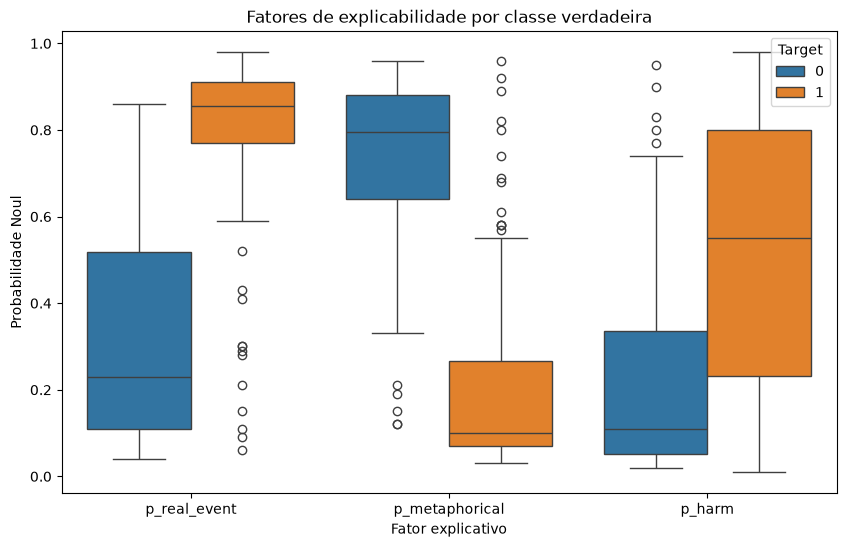

In [34]:
# Converter para formato longo para facilitar a comparação no Seaborn.
explainability_long = explainability.melt(
    id_vars=["target"],
    value_vars=[
        "p_real_event",
        "p_metaphorical",
        "p_harm",
    ],
    var_name="fator",
    value_name="probabilidade",
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=explainability_long,
    x="fator",
    y="probabilidade",
    hue="target",
)

plt.xlabel("Fator explicativo")
plt.ylabel("Probabilidade Noul")
plt.title("Fatores de explicabilidade por classe verdadeira")
plt.legend(title="Target")

plt.show()


### Explicar falsos positivos

Nos falsos positivos, o Jev classificou `desastre`, mas o rótulo real era `não-desastre`.

Os sinais auxiliares ajudam a investigar perguntas como:

- O modelo acreditou que havia um evento real?
- Detectou dano/perigo?
- Também percebeu linguagem metafórica?

Um falso positivo com `p_metaphorical` alto é especialmente interessante: ele pode indicar que o Jev reconheceu a ambiguidade, mas ainda assim atribuiu `P(desastre)` elevada.


In [35]:
false_positive_explanations = explainability[
    (explainability["target"] == 0)
    &
    (explainability["jev_prediction"] == 1)
].sort_values(
    "jev_probability",
    ascending=False
)

false_positive_explanations[
    [
        "text",
        "jev_probability",
        "p_real_event",
        "p_metaphorical",
        "p_harm",
        "explanation",
    ]
].head(20)


,text,jev_probability,p_real_event,p_metaphorical,p_harm,explanation
90,Hey #AZ: Sign this petition to save the #WildH...,0.85,0.53,0.64,0.21,nenhum fator auxiliar ultrapassou o limiar
86,@VictoriaGittins what do you take me for I'm n...,0.82,0.09,0.79,0.19,forte evidência de linguagem metafórica/figura...
62,OH. #TeamHennessy #NJ Obliteration @tprimo24 ...,0.78,0.62,0.88,0.38,forte evidência de linguagem metafórica/figura...
61,@teamVODG Discovered by @NickCannon \n Listen/...,0.77,0.20,0.84,0.10,forte evidência de linguagem metafórica/figura...
88,@Homukami Only URs and SRs matter Rs you'll be...,0.77,0.09,0.91,0.13,forte evidência de linguagem metafórica/figura...
115,Loved the opener and still feeling guilty for ...,0.72,0.61,0.91,0.12,forte evidência de linguagem metafórica/figura...
29,@Papcrdoll and I s2g if my mentions get blown ...,0.70,0.17,0.93,0.08,forte evidência de linguagem metafórica/figura...
60,It's like God wants me to become a mass murder...,0.68,0.12,0.92,0.09,forte evidência de linguagem metafórica/figura...
82,The Danger and Excitement of Underwater Cave D...,0.66,0.15,0.59,0.59,nenhum fator auxiliar ultrapassou o limiar
28,Versions of KS where if a character was /every...,0.65,0.09,0.82,0.26,forte evidência de linguagem metafórica/figura...


### Explicar falsos negativos

Nos falsos negativos, o rótulo real é `desastre`, mas o Jev previu `não-desastre`.

Aqui podemos procurar, por exemplo, tweets em que:

- `p_real_event` é alta, mas `P(desastre)` ficou abaixo do threshold;
- há pouco vocabulário explícito de dano;
- o modelo atribuiu probabilidade relevante a uso metafórico.


In [36]:
false_negative_explanations = explainability[
    (explainability["target"] == 1)
    &
    (explainability["jev_prediction"] == 0)
].sort_values(
    "jev_probability"
)

false_negative_explanations[
    [
        "text",
        "jev_probability",
        "p_real_event",
        "p_metaphorical",
        "p_harm",
        "explanation",
    ]
].head(20)


,text,jev_probability,p_real_event,p_metaphorical,p_harm,explanation
192,you can stab me in the back but I promise you'...,0.03,0.06,0.96,0.80,forte evidência de dano/perigo físico; forte e...
167,That horrible sinking feeling when youÛªve be...,0.03,0.30,0.92,0.03,forte evidência de linguagem metafórica/figura...
137,I just checked in! ÛÒ at On Fire on @ZomatoAU...,0.06,0.41,0.89,0.08,forte evidência de linguagem metafórica/figura...
171,The Prophet (peace be upon him) said 'Save you...,0.06,0.11,0.45,0.09,nenhum fator auxiliar ultrapassou o limiar
139,Swansea Û÷plot hijack transfer move for South...,0.07,0.59,0.69,0.07,nenhum fator auxiliar ultrapassou o limiar
193,@115Film Doctor we must leave immediately the ...,0.15,0.15,0.80,0.95,forte evidência de dano/perigo físico; forte e...
181,@Habbo bring back games from the past. Snowsto...,0.16,0.21,0.58,0.05,nenhum fator auxiliar ultrapassou o limiar
69,I liked a @YouTube video http://t.co/XO2ZbPBJB...,0.17,0.52,0.55,0.25,nenhum fator auxiliar ultrapassou o limiar
170,Manuel hoping for an early Buffalo snowstorm s...,0.17,0.30,0.58,0.09,nenhum fator auxiliar ultrapassou o limiar
94,The Latest: More Homes Razed by Northern Calif...,0.19,0.91,0.10,0.69,forte evidência de evento real


### Relação entre os fatores e `P(desastre)`

Este gráfico permite verificar como os probes auxiliares se relacionam com a decisão principal.

Uma relação positiva entre `p_real_event` / `p_harm` e `jev_probability` seria intuitiva; para `p_metaphorical`, uma relação negativa seria esperada em muitos casos.


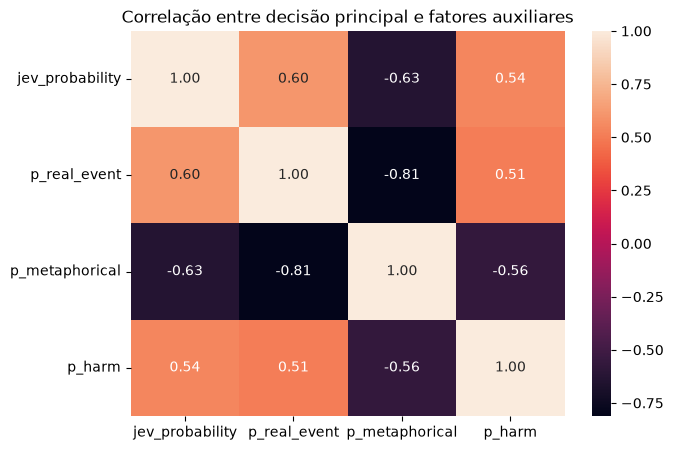

,jev_probability,p_real_event,p_metaphorical,p_harm
jev_probability,1.000000,0.604933,-0.634484,0.544298
p_real_event,0.604933,1.000000,-0.811147,0.509458
p_metaphorical,-0.634484,-0.811147,1.000000,-0.564259
p_harm,0.544298,0.509458,-0.564259,1.000000


In [37]:
factor_correlations = (
    explainability[
        [
            "jev_probability",
            "p_real_event",
            "p_metaphorical",
            "p_harm",
        ]
    ]
    .corr()
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    factor_correlations,
    annot=True,
    fmt=".2f",
)

plt.title("Correlação entre decisão principal e fatores auxiliares")
plt.show()

factor_correlations


### Exemplo individual

A célula abaixo facilita a inspeção de qualquer tweet específico.  
Troque `EXAMPLE_INDEX` por outro índice para investigar diferentes casos, especialmente erros.


In [38]:
EXAMPLE_INDEX = 0

example = explainability.iloc[EXAMPLE_INDEX]

print("Tweet:")
print(example["text"])

print("\nResultado:")
print(f"Target real:       {example['target']}")
print(f"P(desastre):       {example['jev_probability']:.3f}")
print(f"Classe predita:    {example['jev_prediction']}")

print("\nSinais auxiliares:")
print(f"P(evento real):    {example['p_real_event']:.3f}")
print(f"P(metafórico):     {example['p_metaphorical']:.3f}")
print(f"P(dano/perigo):    {example['p_harm']:.3f}")

print("\nExplicação estruturada:")
print(example["explanation"])


Tweet:
Refugio oil spill may have been costlier bigger than projected: A Plains All American Pipeline oil spill off ... http://t.co/yhmrEgAuxZ

Resultado:
Target real:       1
P(desastre):       0.970
Classe predita:    1

Sinais auxiliares:
P(evento real):    0.960
P(metafórico):     0.030
P(dano/perigo):    0.310

Explicação estruturada:
forte evidência de evento real


In [39]:
## Otimização de Threshold

# Testar diferentes thresholds e calcular F1 para cada
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

f1_scores = []

for threshold in thresholds:
    
    # Converter score em predição com threshold
    predictions = (
        y_score >= threshold
    ).astype(int)

    # Calcular F1 score
    score = f1_score(
        y_true,
        predictions
    )

    f1_scores.append(score)

In [40]:
# Compilar resultados de threshold × F1
threshold_results = pd.DataFrame({
    "threshold": thresholds,
    "f1": f1_scores
})

In [41]:
# Encontrar threshold com melhor F1 score
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_row  # threshold=0.34 dá F1=0.759

threshold    0.390000
f1           0.757062
Name: 34, dtype: float64

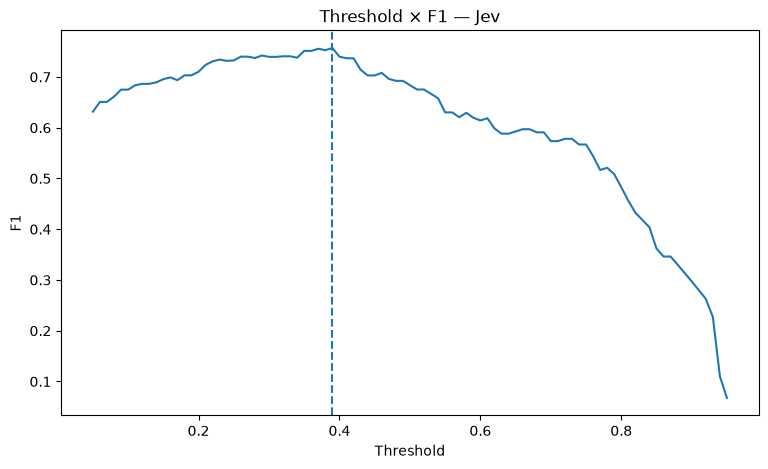

In [42]:
# Visualizar threshold × F1 (encontrar pico)
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=threshold_results,
    x="threshold",
    y="f1"
)

plt.axvline(
    best_row["threshold"],
    linestyle="--"
)

plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Threshold × F1 — Jev")

plt.show()